# Lab 5: Project Networks — CPM, PERT, and Gantt Charts

In Lab 4 you scheduled operations inside a robot cell. That was a **job-shop** problem: several jobs competed for the same physical stations, so binary variables were needed to decide which job used a station first.

This lab looks one level higher. A robotics team must deliver a working demonstration project. The question is no longer *which robot uses a station first?* but:

- Which project tasks can run in parallel?
- Which tasks determine the earliest possible finish date?
- Which delays are harmless, and which delays move the whole project?
- When is it worth paying more for faster delivery or extra risk reduction?

The main tools are:

- **Critical Path Method (CPM)** for deterministic task durations,
- **PERT** for uncertain task durations,
- **Gantt charts** for communicating the project schedule and slack.


## Learning goals

After this lab you should be able to:

1. translate a robotics-project story into tasks, durations, and precedence constraints,
2. compute earliest start/finish, latest start/finish, slack, and the critical path,
3. explain why speeding up a non-critical task may save **zero** calendar time,
4. draw and interpret a project Gantt chart,
5. use PERT estimates to approximate deadline risk,
6. compare project decisions: faster suppliers, crashing, and risk-mitigation tasks.

Suggested time: **90–120 minutes**.


## Story: preparing an autonomous inspection robot demo

The lab is preparing an autonomous inspection robot for an open-day demonstration. The robot must navigate a small production cell, inspect a part, and report the result to visitors.

Management wants the deterministic plan shortened to **30 days** if possible. The team has three possible levers:

1. choose a faster but more expensive supplier for selected components,
2. crash selected engineering tasks by assigning extra people or overtime,
3. add a short risk-reduction review that does not look productive on the Gantt chart but may reduce uncertainty later.

The important question is not "which option is fastest in isolation?" It is "which option shortens the **critical path** or reduces deadline risk enough to justify its cost?"


## Project overview

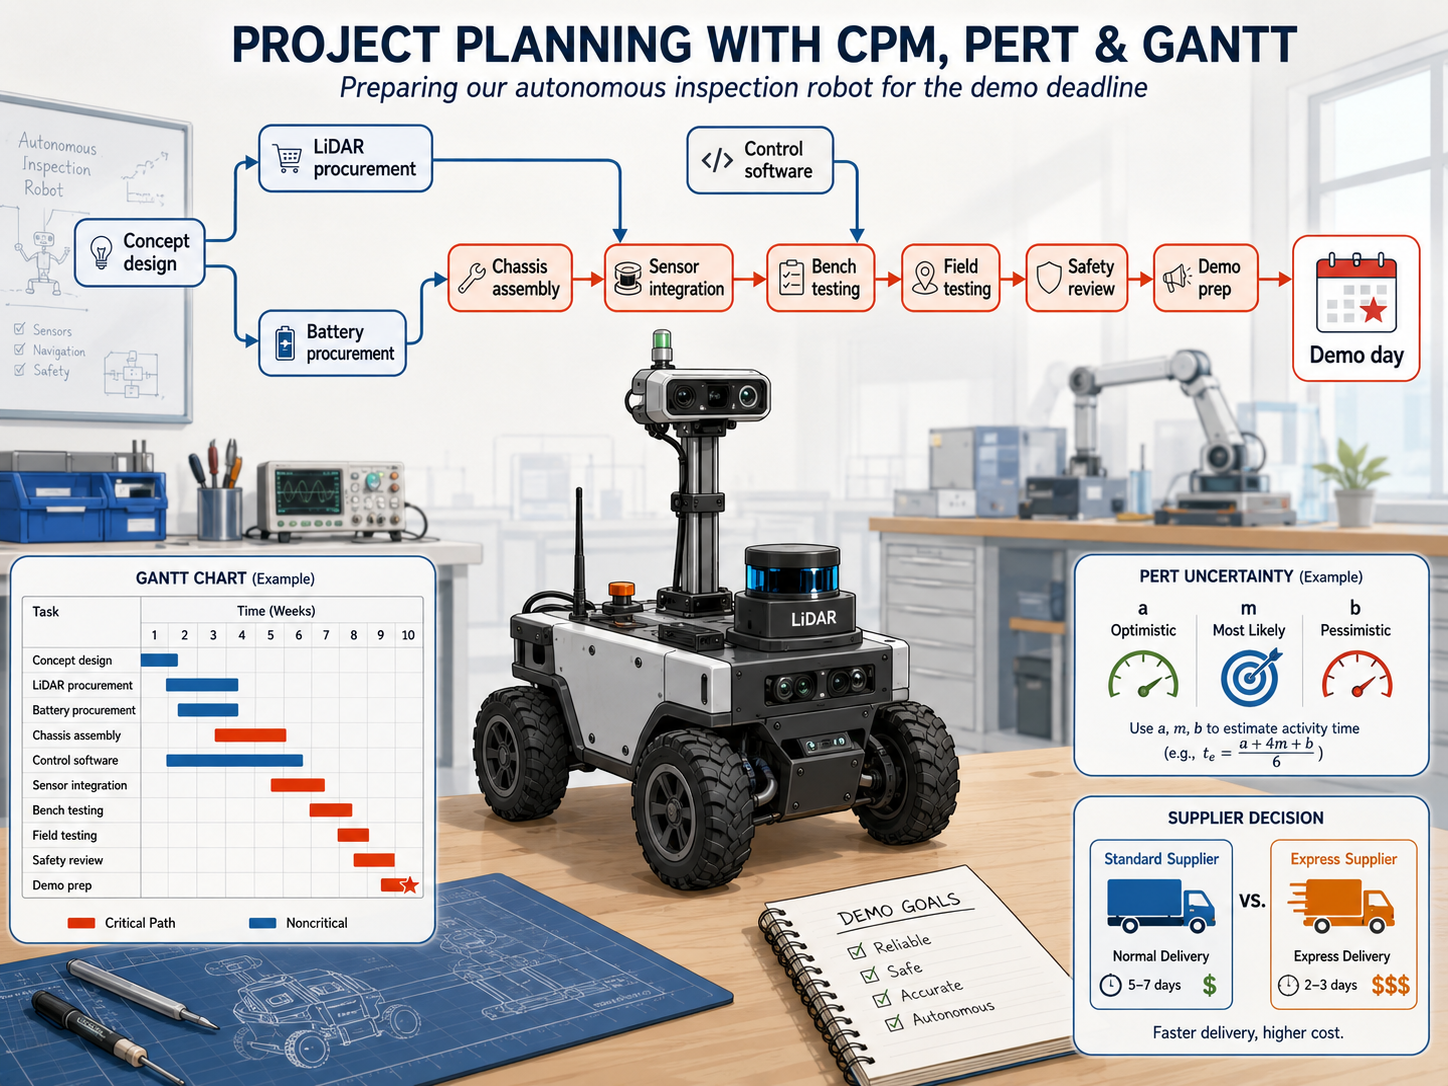

The same illustration is also included in the repository as `lab_auto_5_illustration.png` for environments that prefer file assets.


## Warm-up by hand: a four-task network

Before using Python, solve this small example on paper.

| Task | Duration | Predecessors |
|:---:|---:|:---|
| A | 2 | — |
| B | 3 | — |
| C | 5 | A, B |
| D | 4 | C |

Answer without code:

1. What are ES and EF for each task?
2. What are LS and LF for each task if the project finishes as early as possible?
3. Which tasks have zero slack?
4. What is the critical path?
5. If task A is shortened by 1 day, does the project finish earlier? Why?


## Imports and runtime setup

The lab is designed for Google Colab and local Jupyter. Run the next cell once. If a package is missing, the cell installs the required packages into the current notebook runtime.


In [ ]:
try:
    from itertools import product
    from math import erf, sqrt

    import matplotlib.pyplot as plt
    import networkx as nx
    import numpy as np
    import pandas as pd
except ModuleNotFoundError:
    # In Colab this installs into the notebook runtime.
    # Locally, prefer a virtual environment and `pip install -r requirements.txt`.
    %pip install numpy pandas matplotlib networkx

    from itertools import product
    from math import erf, sqrt

    import matplotlib.pyplot as plt
    import networkx as nx
    import numpy as np
    import pandas as pd


## Main project data

Durations are in **days**. The `predecessors` column lists tasks that must finish before the task can start.

The columns `a`, `m`, and `b` are PERT estimates:

- `a`: optimistic duration,
- `m`: most likely duration,
- `b`: pessimistic duration.

For CPM, we first use the fixed `duration` column. Later, for PERT, we compute an expected duration from `a`, `m`, and `b`.


In [ ]:
project_tasks = pd.DataFrame([
    {
        "id": "A",
        "task": "Define demo requirements",
        "owner": "Project lead",
        "duration": 2,
        "predecessors": [],
        "a": 1,
        "m": 2,
        "b": 3,
    },
    {
        "id": "B",
        "task": "Safety approval for test area",
        "owner": "Safety officer",
        "duration": 4,
        "predecessors": ["A"],
        "a": 3,
        "m": 4,
        "b": 7,
    },
    {
        "id": "C",
        "task": "Software architecture and interfaces",
        "owner": "Software team",
        "duration": 4,
        "predecessors": ["A"],
        "a": 3,
        "m": 4,
        "b": 7,
    },
    {
        "id": "D",
        "task": "LiDAR sensor delivery",
        "owner": "Procurement",
        "duration": 8,
        "predecessors": ["A"],
        "a": 5,
        "m": 8,
        "b": 13,
    },
    {
        "id": "E",
        "task": "Battery module delivery",
        "owner": "Procurement",
        "duration": 5,
        "predecessors": ["A"],
        "a": 3,
        "m": 5,
        "b": 9,
    },
    {
        "id": "F",
        "task": "Build chassis",
        "owner": "Mechanical team",
        "duration": 6,
        "predecessors": ["A"],
        "a": 4,
        "m": 6,
        "b": 9,
    },
    {
        "id": "G",
        "task": "Prepare simulation scenario",
        "owner": "Simulation team",
        "duration": 4,
        "predecessors": ["B", "C"],
        "a": 3,
        "m": 4,
        "b": 6,
    },
    {
        "id": "H",
        "task": "Assemble electronics and perception",
        "owner": "Integration team",
        "duration": 5,
        "predecessors": ["D", "E", "F"],
        "a": 4,
        "m": 5,
        "b": 9,
    },
    {
        "id": "I",
        "task": "Integrate navigation software",
        "owner": "Software team",
        "duration": 6,
        "predecessors": ["C", "H"],
        "a": 4,
        "m": 6,
        "b": 10,
    },
    {
        "id": "J",
        "task": "Bench safety tests",
        "owner": "Safety officer",
        "duration": 4,
        "predecessors": ["B", "I"],
        "a": 3,
        "m": 4,
        "b": 8,
    },
    {
        "id": "K",
        "task": "Field test in robot cell",
        "owner": "Robotics team",
        "duration": 5,
        "predecessors": ["G", "J"],
        "a": 3,
        "m": 5,
        "b": 11,
    },
    {
        "id": "L",
        "task": "Demo script and operator training",
        "owner": "Teaching assistant",
        "duration": 3,
        "predecessors": ["A"],
        "a": 2,
        "m": 3,
        "b": 4,
    },
    {
        "id": "M",
        "task": "Final demo rehearsal",
        "owner": "Whole team",
        "duration": 2,
        "predecessors": ["K", "L"],
        "a": 1,
        "m": 2,
        "b": 4,
    },
    {
        "id": "N",
        "task": "Ready for open day",
        "owner": "Project lead",
        "duration": 1,
        "predecessors": ["M"],
        "a": 1,
        "m": 1,
        "b": 2,
    },
])

project_tasks


## CPM implementation

CPM is two passes through a directed acyclic graph.

### Forward pass

For each task:

\[
ES_i = \max_{p \in pred(i)} EF_p
\]

\[
EF_i = ES_i + duration_i
\]

### Backward pass

For each task, going backward from the project finish:

\[
LF_i = \min_{s \in succ(i)} LS_s
\]

\[
LS_i = LF_i - duration_i
\]

Slack is:

\[
slack_i = LS_i - ES_i
\]

Tasks with zero slack are critical.


In [ ]:
def validate_project_data(tasks):
    """Check basic project-network assumptions before scheduling."""
    ids = list(tasks["id"])
    if len(ids) != len(set(ids)):
        raise ValueError("Task IDs must be unique.")

    known_ids = set(ids)
    missing = []
    for row in tasks.itertuples(index=False):
        for predecessor in row.predecessors:
            if predecessor not in known_ids:
                missing.append((row.id, predecessor))
    if missing:
        raise ValueError(f"Unknown predecessor references: {missing}")


def build_project_graph(tasks):
    """Build a precedence graph: edge u -> v means u must finish before v starts."""
    validate_project_data(tasks)
    graph = nx.DiGraph()
    graph.add_nodes_from(tasks["id"])

    for row in tasks.itertuples(index=False):
        for predecessor in row.predecessors:
            graph.add_edge(predecessor, row.id)

    # CPM only works on acyclic precedence networks.
    if not nx.is_directed_acyclic_graph(graph):
        cycle = nx.find_cycle(graph)
        raise ValueError(f"The project network contains a cycle: {cycle}")
    return graph


def compute_cpm(tasks, duration_col="duration", tolerance=1e-9):
    """Return a CPM table, the project graph, and the project duration."""
    tasks = tasks.copy(deep=True)
    graph = build_project_graph(tasks)
    order = list(nx.topological_sort(graph))
    duration = dict(zip(tasks["id"], tasks[duration_col]))

    # Forward pass: each task starts after all predecessors have finished.
    earliest_start = {}
    earliest_finish = {}
    for task_id in order:
        predecessor_finishes = [earliest_finish[p] for p in graph.predecessors(task_id)]
        earliest_start[task_id] = max(predecessor_finishes) if predecessor_finishes else 0
        earliest_finish[task_id] = earliest_start[task_id] + duration[task_id]

    project_duration = max(earliest_finish.values())

    # Backward pass: move from the project finish back toward the first tasks.
    # A task with successors must finish before the earliest latest-start of those successors.
    latest_finish = {}
    latest_start = {}
    for task_id in reversed(order):
        successor_starts = [latest_start[s] for s in graph.successors(task_id)]
        latest_finish[task_id] = min(successor_starts) if successor_starts else project_duration
        latest_start[task_id] = latest_finish[task_id] - duration[task_id]

    result = tasks.set_index("id").loc[order].reset_index()
    result["duration_used"] = result[duration_col]
    result["ES"] = result["id"].map(earliest_start)
    result["EF"] = result["id"].map(earliest_finish)
    result["LS"] = result["id"].map(latest_start)
    result["LF"] = result["id"].map(latest_finish)
    result["slack"] = result["LS"] - result["ES"]
    result["critical"] = result["slack"].abs() <= tolerance
    result["successors"] = result["id"].apply(lambda task_id: list(graph.successors(task_id)))
    return result, graph, project_duration


def critical_edges(cpm_table, graph, tolerance=1e-7):
    """Edges that lie on at least one critical path."""
    metrics = cpm_table.set_index("id")
    critical_nodes = set(cpm_table.loc[cpm_table["critical"], "id"])
    edges = []
    for source, target in graph.edges():
        if source in critical_nodes and target in critical_nodes:
            # Critical nodes form a continuous path only when the predecessor finish
            # equals the successor start. Otherwise there is a gap between them.
            touches_without_gap = abs(metrics.loc[source, "EF"] - metrics.loc[target, "ES"]) <= tolerance
            if touches_without_gap:
                edges.append((source, target))
    return edges


def one_critical_path(cpm_table, graph, tolerance=1e-7):
    """Return one critical path. If there are several, return one of the longest."""
    metrics = cpm_table.set_index("id")
    project_duration = cpm_table["EF"].max()

    critical_graph = nx.DiGraph()
    critical_nodes = list(cpm_table.loc[cpm_table["critical"], "id"])
    critical_graph.add_nodes_from(critical_nodes)
    critical_graph.add_edges_from(critical_edges(cpm_table, graph, tolerance=tolerance))

    starts = [
        node for node in critical_graph.nodes
        if critical_graph.in_degree(node) == 0 and abs(metrics.loc[node, "ES"]) <= tolerance
    ]
    ends = [
        node for node in critical_graph.nodes
        if critical_graph.out_degree(node) == 0 and abs(metrics.loc[node, "EF"] - project_duration) <= tolerance
    ]

    best_path = []
    best_duration = -1
    durations = (metrics["EF"] - metrics["ES"]).to_dict()
    for start in starts:
        for end in ends:
            for path in nx.all_simple_paths(critical_graph, start, end):
                path_duration = sum(durations[node] for node in path)
                if path_duration > best_duration:
                    best_duration = path_duration
                    best_path = path
    return best_path


## Baseline CPM result

Run CPM for the deterministic `duration` column.


In [ ]:
baseline_cpm, baseline_graph, baseline_duration = compute_cpm(project_tasks, duration_col="duration")

# The table gives all ingredients for the CPM interpretation.
# Do not look for a preprinted critical path: use zero slack and precedence order.
baseline_cpm[[
    "id", "task", "duration", "predecessors", "successors", "ES", "EF", "LS", "LF", "slack"
]]


### Task 1 — interpret the baseline

Answer in your notebook before running the visualization cells:

1. What is the earliest possible project finish day? Explain where you read it from.
2. Which tasks have zero slack?
3. Connect the zero-slack tasks into one valid critical path using the predecessor/successor columns.
4. Which non-critical task has the most slack?
5. Which procurement task is more dangerous if delayed: LiDAR delivery or battery delivery?
6. Compare this with Lab 4: why is "critical path" not the same idea as a "busy station"?


## Network and Gantt visualizations

The network diagram shows precedence. The Gantt chart shows earliest starts, task lengths, and slack.

This project Gantt chart is different from the job-shop Gantt chart in Lab 4. Here, a row is a **project task**, not a physical station. Overlap is allowed whenever precedence constraints allow it.


In [ ]:
def plot_project_network(cpm_table, graph, title="Project network"):
    """Draw the precedence graph and highlight critical nodes/edges."""
    table = cpm_table.set_index("id")

    # Position nodes by earliest start; stack nodes with similar ES vertically.
    groups = cpm_table.groupby("ES")["id"].apply(list).to_dict()
    pos = {}
    for x, task_ids in groups.items():
        offset = (len(task_ids) - 1) / 2
        for j, task_id in enumerate(task_ids):
            pos[task_id] = (float(x), -(j - offset))

    node_colors = ["#d62728" if table.loc[node, "critical"] else "#8ecae6" for node in graph.nodes]
    edge_colors = ["#d62728" if edge in critical_edges(cpm_table, graph) else "#999999" for edge in graph.edges]
    edge_widths = [2.8 if edge in critical_edges(cpm_table, graph) else 1.2 for edge in graph.edges]
    labels = {
        node: f"{node}\n{table.loc[node, 'duration_used']:g} d\nslack {table.loc[node, 'slack']:g}"
        for node in graph.nodes
    }

    fig, ax = plt.subplots(figsize=(13, 7))
    nx.draw_networkx_edges(
        graph, pos, ax=ax, edge_color=edge_colors, width=edge_widths,
        arrows=True, arrowsize=16, connectionstyle="arc3,rad=0.05"
    )
    nx.draw_networkx_nodes(
        graph, pos, ax=ax, node_color=node_colors,
        node_size=1800, edgecolors="black", linewidths=1
    )
    nx.draw_networkx_labels(graph, pos, labels=labels, ax=ax, font_size=8)
    ax.set_title(title)
    ax.set_xlabel("Earliest start day")
    ax.set_yticks([])
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)
    plt.tight_layout()
    return fig, ax


def plot_project_gantt(cpm_table, deadline=None, title="Project Gantt chart"):
    """Draw earliest-start Gantt bars and slack windows."""
    plot_table = cpm_table.sort_values(["ES", "EF", "id"], ascending=[True, True, True]).reset_index(drop=True)
    y_positions = np.arange(len(plot_table))

    fig, ax = plt.subplots(figsize=(13, 0.55 * len(plot_table) + 2.5))
    for y, row in zip(y_positions, plot_table.itertuples(index=False)):
        task_color = "#d62728" if row.critical else "#1f77b4"
        ax.barh(y, row.duration_used, left=row.ES, color=task_color, edgecolor="black")
        ax.text(row.ES + row.duration_used / 2, y, row.id, ha="center", va="center", color="white", weight="bold")

        if row.slack > 1e-9:
            ax.barh(y, row.slack, left=row.EF, color="#cccccc", edgecolor="#666666", alpha=0.55, hatch="//")
            ax.text(row.EF + row.slack / 2, y, f"slack {row.slack:g}", ha="center", va="center", fontsize=8)

    if deadline is not None:
        ax.axvline(deadline, linestyle="--", linewidth=2, color="black", label=f"deadline day {deadline}")
        ax.legend(loc="lower right")

    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_table["task"])
    ax.invert_yaxis()
    ax.set_xlabel("Project day")
    ax.set_title(title)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)
    plt.tight_layout()
    return fig, ax


In [ ]:
plot_project_network(baseline_cpm, baseline_graph, title="Baseline project network: critical path in red");


In [ ]:
plot_project_gantt(baseline_cpm, deadline=30, title="Baseline project Gantt chart");


### Task 2 — read the Gantt chart

Use the Gantt chart to answer:

1. Which tasks can start immediately after task A?
2. Which tasks finish early but do not control the final date?
3. If task L is delayed by 10 days, does the project finish later?
4. If task D is delayed by 2 days, does the project finish later?
5. Which slack values are most useful to communicate to a project manager?


## Decision layer 1: two distributors

Procurement offers two faster but more expensive delivery choices.

The tempting but wrong rule is: "faster is always better." CPM gives a better rule:

> Pay for a faster option only when the option affects a path that can become or remain critical.


In [ ]:
supplier_options = pd.DataFrame([
    {
        "component": "LiDAR sensors",
        "task_id": "D",
        "standard_duration": 8,
        "express_duration": 5,
        "extra_cost": 2400,
        "comment": "Specialized sensor distributor with priority shipment",
    },
    {
        "component": "Battery modules",
        "task_id": "E",
        "standard_duration": 5,
        "express_duration": 3,
        "extra_cost": 1200,
        "comment": "Local battery distributor with same-week shipment",
    },
])

supplier_options


In [ ]:
def apply_duration_changes(tasks, changes):
    """Return a copy of tasks with selected task durations replaced."""
    updated = tasks.copy(deep=True)
    for task_id, new_duration in changes.items():
        if task_id not in set(updated["id"]):
            raise ValueError(f"Unknown task id: {task_id}")
        updated.loc[updated["id"] == task_id, "duration"] = new_duration
    return updated


def evaluate_duration_scenario(tasks, label, changes=None, extra_cost=0):
    """Evaluate one deterministic supplier scenario."""
    changes = changes or {}
    scenario_tasks = apply_duration_changes(tasks, changes)
    scenario_cpm, scenario_graph, scenario_duration = compute_cpm(scenario_tasks, duration_col="duration")
    days_saved = baseline_duration - scenario_duration
    cost_per_day = extra_cost / days_saved if days_saved > 0 else np.inf if extra_cost > 0 else 0
    summary = {
        "scenario": label,
        "project_duration": scenario_duration,
        "days_saved_vs_baseline": days_saved,
        "extra_cost": extra_cost,
        "cost_per_day_saved": cost_per_day,
        "critical_path": " -> ".join(one_critical_path(scenario_cpm, scenario_graph)),
    }
    return summary, scenario_cpm, scenario_graph


# TODO: add the missing supplier scenarios from the table above.
# Start by running the standard case. Then add LiDAR express, battery express, and both.
supplier_scenarios = [
    ("standard suppliers", {}, 0),
    # ("express LiDAR only", {"D": 5}, 2400),
    # ("express battery only", {"E": 3}, 1200),
    # ("express both", {"D": 5, "E": 3}, 3600),
]

supplier_results = []
for label, changes, cost in supplier_scenarios:
    summary, _, _ = evaluate_duration_scenario(project_tasks, label, changes, cost)
    supplier_results.append(summary)

supplier_results_table = pd.DataFrame(supplier_results)
supplier_results_table


### Task 3 — supplier decision

Modify the scenario cell above, then answer:

1. Which express supplier shortens the project?
2. Which express supplier does not shorten the project? Explain using slack.
3. Why does the 3-day faster LiDAR delivery not necessarily save 3 project days?
4. Which task becomes important after LiDAR delivery is accelerated?
5. Would you pay for both express suppliers? Justify your answer using days saved and cost.


## Decision layer 2: crashing tasks

Crashing means reducing a task duration by spending extra money, overtime, or additional staff.

Crashing is not the same as blindly reducing all long tasks. A long non-critical task may have enough slack that shortening it has no effect.


In [ ]:
crash_options = pd.DataFrame([
    {
        "task_id": "F",
        "task": "Build chassis",
        "max_reduction": 2,
        "cost_per_day": 900,
        "note": "Add a second technician and use pre-cut mounting plates",
    },
    {
        "task_id": "H",
        "task": "Assemble electronics and perception",
        "max_reduction": 2,
        "cost_per_day": 1400,
        "note": "Overtime for integration team",
    },
    {
        "task_id": "I",
        "task": "Integrate navigation software",
        "max_reduction": 3,
        "cost_per_day": 1600,
        "note": "Borrow a senior developer from another project",
    },
    {
        "task_id": "J",
        "task": "Bench safety tests",
        "max_reduction": 1,
        "cost_per_day": 1700,
        "note": "Weekend safety review",
    },
    {
        "task_id": "K",
        "task": "Field test in robot cell",
        "max_reduction": 2,
        "cost_per_day": 2000,
        "note": "Book evening test slots and extra operator",
    },
])

crash_options


In [ ]:
def apply_crash_plan(tasks, reductions):
    """Reduce selected task durations by integer day amounts."""
    updated = tasks.copy(deep=True)
    base_duration = dict(zip(updated["id"], updated["duration"]))
    for task_id, reduction in reductions.items():
        if reduction < 0:
            raise ValueError("Reduction cannot be negative.")
        if task_id not in base_duration:
            raise ValueError(f"Unknown task id: {task_id}")
        updated.loc[updated["id"] == task_id, "duration"] = max(0, base_duration[task_id] - reduction)
    return updated


def evaluate_full_plan(tasks, supplier_changes=None, crash_reductions=None):
    """Evaluate a plan with supplier duration changes and crash reductions."""
    supplier_changes = supplier_changes or {}
    crash_reductions = crash_reductions or {}
    updated = apply_duration_changes(tasks, supplier_changes)
    updated = apply_crash_plan(updated, crash_reductions)
    cpm_table, graph, duration = compute_cpm(updated, duration_col="duration")
    return updated, cpm_table, graph, duration


def enumerate_supplier_and_crash_plans(tasks, crash_options, deadline=30):
    """Brute-force supplier choices and integer crash reductions."""
    supplier_cases = [
        ("standard suppliers", {}, 0),
        ("express LiDAR", {"D": 5}, 2400),
        ("express battery", {"E": 3}, 1200),
        ("express both", {"D": 5, "E": 3}, 3600),
    ]

    crash_ranges = [range(int(row.max_reduction) + 1) for row in crash_options.itertuples(index=False)]
    crash_task_ids = list(crash_options["task_id"])
    cost_per_day = dict(zip(crash_options["task_id"], crash_options["cost_per_day"]))

    rows = []
    for supplier_label, supplier_changes, supplier_cost in supplier_cases:
        for values in product(*crash_ranges):
            reductions = dict(zip(crash_task_ids, values))
            _, cpm_table, graph, duration = evaluate_full_plan(
                tasks,
                supplier_changes=supplier_changes,
                crash_reductions=reductions,
            )
            crash_cost = sum(reductions[task_id] * cost_per_day[task_id] for task_id in crash_task_ids)
            total_cost = supplier_cost + crash_cost
            rows.append({
                "supplier_choice": supplier_label,
                "crash_reductions": reductions,
                "project_duration": duration,
                "days_saved_vs_baseline": baseline_duration - duration,
                "total_extra_cost": total_cost,
                "meets_deadline": duration <= deadline,
                "critical_path": " -> ".join(one_critical_path(cpm_table, graph)),
            })

    # Return the raw enumeration order. Students will decide how to filter and sort it.
    return pd.DataFrame(rows)


In [ ]:
deadline = 30
plans = enumerate_supplier_and_crash_plans(project_tasks, crash_options, deadline=deadline)

print(f"Generated {len(plans)} candidate plans. The first rows are not ranked.")
plans[[
    "supplier_choice", "crash_reductions", "project_duration", "total_extra_cost", "meets_deadline"
]].head(8)


### Task 4 — choose a plan

The open-day target is day 30.

1. Filter `plans` to plans that meet the deadline, then sort by `total_extra_cost`.
2. Find the cheapest plan that meets the target.
3. Explain why that plan is cheaper than crashing only the obvious critical tasks in the baseline schedule.
4. Enter your chosen supplier changes and crash reductions in the next cell.
5. After applying the chosen plan, re-plot the Gantt chart.
6. Identify the new critical path. Did it change?


In [ ]:
# TODO: replace these dictionaries with your chosen plan from Task 4.
# Keep the baseline placeholders first, then edit and rerun.
selected_supplier_changes = {}
selected_crash_reductions = {}

selected_tasks, selected_cpm, selected_graph, selected_duration = evaluate_full_plan(
    project_tasks,
    supplier_changes=selected_supplier_changes,
    crash_reductions=selected_crash_reductions,
)

print(f"Selected plan duration: {selected_duration:.0f} days")
print(f"Meets day-{deadline} deadline: {selected_duration <= deadline}")

selected_cpm[["id", "task", "duration", "ES", "EF", "LS", "LF", "slack"]]


In [ ]:
plot_project_gantt(selected_cpm, deadline=deadline, title="Selected plan Gantt chart");


## PERT: uncertain durations and deadline risk

CPM assumes fixed durations. PERT replaces a fixed duration with three estimates:

\[
E = \frac{a + 4m + b}{6}
\]

\[
\sigma^2 = \left(\frac{b-a}{6}\right)^2
\]

A common approximation is to sum variances along the critical path and approximate project finish time with a normal distribution. This is useful, but it has a limitation: the critical path itself can change under uncertainty.


In [ ]:
def add_pert_columns(tasks):
    """Add PERT expected duration and variance columns."""
    result = tasks.copy(deep=True)
    result["expected_duration"] = (result["a"] + 4 * result["m"] + result["b"]) / 6
    result["variance"] = ((result["b"] - result["a"]) / 6) ** 2
    return result


def normal_cdf(z):
    """Standard normal cumulative distribution function."""
    return 0.5 * (1 + erf(z / sqrt(2)))


def pert_summary(tasks, deadline):
    """Compute PERT CPM table and approximate probability of meeting a deadline."""
    pert_tasks = add_pert_columns(tasks)
    cpm_table, graph, expected_duration = compute_cpm(pert_tasks, duration_col="expected_duration")
    path = one_critical_path(cpm_table, graph)

    metrics = cpm_table.set_index("id")
    # PERT approximation: sum variances only along the expected critical path.
    critical_path_variance = metrics.loc[path, "variance"].sum()
    critical_path_std = sqrt(critical_path_variance)

    if critical_path_std > 0:
        z = (deadline - expected_duration) / critical_path_std
        probability = normal_cdf(z)
    else:
        z = np.inf if deadline >= expected_duration else -np.inf
        probability = float(deadline >= expected_duration)

    summary = {
        "deadline": deadline,
        "expected_project_duration": expected_duration,
        "critical_path": " -> ".join(path),
        "critical_path_variance": critical_path_variance,
        "critical_path_std_dev": critical_path_std,
        "z_value": z,
        "approx_probability_finish_by_deadline": probability,
    }
    return cpm_table, graph, summary


In [ ]:
risk_deadline = 36
pert_cpm, pert_graph, pert_stats = pert_summary(project_tasks, deadline=risk_deadline)

# First inspect the task-level PERT table in the next cell.
# After writing your estimate, uncomment the final line to check the full summary.
pert_stats_for_check = pd.DataFrame([pert_stats])
# pert_stats_for_check


In [ ]:
pert_cpm[[
    "id", "task", "a", "m", "b", "expected_duration", "variance", "ES", "EF", "slack"
]]


### Task 5 — PERT interpretation

Use the task-level PERT table first. Then uncomment `pert_stats_for_check` in the previous cell to check your numerical probability.

1. Which tasks have the largest uncertainty? Look at the variance column.
2. Which uncertain tasks are on the PERT critical path? Use zero slack and precedence order.
3. What is the approximate probability of finishing by the risk deadline?
4. Why should this probability be treated as an approximation rather than a guarantee?


## Decision layer 3: adding a risk-reduction task

The integration team proposes a **1-day sensor interface review** before electronics assembly.

At first it looks like extra work. However, it prevents wiring/interface mistakes and makes electronics assembly more predictable.

Assumption for this exercise:

- Add task `R`: Sensor interface review, duration 1 day, after D, E, and F.
- Change task H so it depends on R instead of directly on D, E, and F.
- Reduce task H from 5 to 4 deterministic days.
- Reduce task H PERT estimates from `(a=4, m=5, b=9)` to `(a=3, m=4, b=5)`.

This is an example where adding a task may reduce risk and may even reduce expected duration.


In [ ]:
def add_sensor_interface_review(tasks):
    """Add a 1-day risk-reduction task before electronics assembly."""
    updated = tasks.copy(deep=True)

    h_index = updated.index[updated["id"] == "H"][0]
    updated.at[h_index, "predecessors"] = ["R"]
    updated.loc[h_index, ["duration", "a", "m", "b"]] = [4, 3, 4, 5]

    review_task = pd.DataFrame([{
        "id": "R",
        "task": "Sensor interface review",
        "owner": "Integration team",
        "duration": 1,
        "predecessors": ["D", "E", "F"],
        "a": 1,
        "m": 1,
        "b": 1,
    }])

    return pd.concat([updated, review_task], ignore_index=True)


mitigated_tasks = add_sensor_interface_review(project_tasks)
mitigated_cpm, mitigated_graph, mitigated_duration = compute_cpm(mitigated_tasks, duration_col="duration")
mitigated_pert_cpm, mitigated_pert_graph, mitigated_pert_stats = pert_summary(mitigated_tasks, deadline=risk_deadline)

risk_comparison = pd.DataFrame([
    {"case": "original", "deterministic_duration": baseline_duration, **pert_stats},
    {"case": "with sensor interface review", "deterministic_duration": mitigated_duration, **mitigated_pert_stats},
])

# Predict the direction of the change before displaying this table.
# risk_comparison


In [ ]:
plot_project_gantt(mitigated_cpm, deadline=deadline, title="Deterministic schedule with sensor interface review");


### Task 6 — risk-reduction decision

Answer:

1. Does the review change the deterministic project duration?
2. Does it change the expected project duration under PERT?
3. Does it change the approximate probability of finishing by the risk deadline?
4. Would you add the review if it costs 900 PLN? Justify your answer.
5. How is this decision different from simply crashing a task?


## Challenge: Monte Carlo simulation

PERT's normal approximation assumes that the current critical path remains the relevant path. A simulation can test that assumption by repeatedly sampling durations and recomputing the project duration.

This challenge uses a scaled beta distribution with shape parameters chosen so that the sample mean matches the PERT expected duration:

\[
E = \frac{a + 4m + b}{6}
\]

The simulation is still an approximation, but it makes one limitation visible: different sampled scenarios can have different critical paths.


In [ ]:
def sample_pert_beta_durations(tasks, rng, weight=4):
    """Sample task durations from a scaled beta-PERT distribution."""
    a = tasks["a"].to_numpy(dtype=float)
    m = tasks["m"].to_numpy(dtype=float)
    b = tasks["b"].to_numpy(dtype=float)

    sampled = np.empty(len(tasks), dtype=float)
    deterministic = np.isclose(a, b)
    sampled[deterministic] = a[deterministic]

    variable = ~deterministic
    width = b[variable] - a[variable]
    alpha = 1 + weight * (m[variable] - a[variable]) / width
    beta = 1 + weight * (b[variable] - m[variable]) / width
    sampled[variable] = a[variable] + rng.beta(alpha, beta) * width
    return sampled


def project_duration_from_duration_vector(tasks, duration_values, graph=None, order=None):
    """Fast forward-pass project duration for repeated simulations."""
    if graph is None:
        graph = build_project_graph(tasks)
    if order is None:
        order = list(nx.topological_sort(graph))

    duration = dict(zip(tasks["id"], duration_values))
    earliest_finish = {}
    for task_id in order:
        predecessor_finishes = [earliest_finish[p] for p in graph.predecessors(task_id)]
        earliest_start = max(predecessor_finishes) if predecessor_finishes else 0
        earliest_finish[task_id] = earliest_start + duration[task_id]
    return max(earliest_finish.values())


def monte_carlo_project_duration(tasks, trials=3000, seed=42):
    """Sample many uncertain schedules and return simulated project durations."""
    rng = np.random.default_rng(seed)
    graph = build_project_graph(tasks)
    order = list(nx.topological_sort(graph))
    finishes = np.empty(trials, dtype=float)

    for trial in range(trials):
        sampled = sample_pert_beta_durations(tasks, rng)
        finishes[trial] = project_duration_from_duration_vector(tasks, sampled, graph=graph, order=order)

    return pd.Series(finishes, name="project_duration")


In [ ]:
sim_original = monte_carlo_project_duration(project_tasks, trials=3000, seed=1)
sim_mitigated = monte_carlo_project_duration(mitigated_tasks, trials=3000, seed=1)

simulation_summary = pd.DataFrame([
    {
        "case": "original",
        "mean": sim_original.mean(),
        "p50": sim_original.quantile(0.50),
        "p90": sim_original.quantile(0.90),
        "prob_finish_by_risk_deadline": (sim_original <= risk_deadline).mean(),
    },
    {
        "case": "with sensor interface review",
        "mean": sim_mitigated.mean(),
        "p50": sim_mitigated.quantile(0.50),
        "p90": sim_mitigated.quantile(0.90),
        "prob_finish_by_risk_deadline": (sim_mitigated <= risk_deadline).mean(),
    },
])

simulation_summary


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sim_original, bins=30, alpha=0.55, label="original")
ax.hist(sim_mitigated, bins=30, alpha=0.55, label="with sensor interface review")
ax.axvline(risk_deadline, linestyle="--", color="black", label=f"risk deadline day {risk_deadline}")
ax.set_xlabel("Simulated project duration [days]")
ax.set_ylabel("Frequency")
ax.set_title("Monte Carlo project-duration simulation")
ax.legend()
plt.tight_layout()


### Challenge questions

1. Compare the PERT normal approximation with the Monte Carlo result. Are they close?
2. Which result would you present to management? Why?
3. Extend the simulation to the selected supplier/crashing plan.
4. Find a plan that gives at least an 80% simulated probability of finishing by the risk deadline.


## Final report template

Submit a short report with these sections:

### 1. Baseline CPM

- Project duration:
- Critical path:
- Three tasks with highest slack:
- One sentence explaining why slack matters:

### 2. Supplier decision

- Recommended supplier changes:
- Days saved:
- Cost:
- Why the other supplier option is or is not useful:

### 3. Crashing decision

- Recommended crash plan:
- New project duration:
- Total cost:
- New critical path:

### 4. PERT risk

- Expected project duration:
- Deadline probability:
- Main source of risk:
- Recommendation about the sensor interface review:

### 5. Reflection

Explain in 3–5 sentences how project Gantt charts in this lab differ from station Gantt charts in Lab 4.
